In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [5]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)
df= pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))

Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


In [7]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [12]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [13]:
df.shape

(48895, 16)

EDA

In [16]:
missing = df.isnull().sum()
missing[missing >0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

In [17]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [19]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

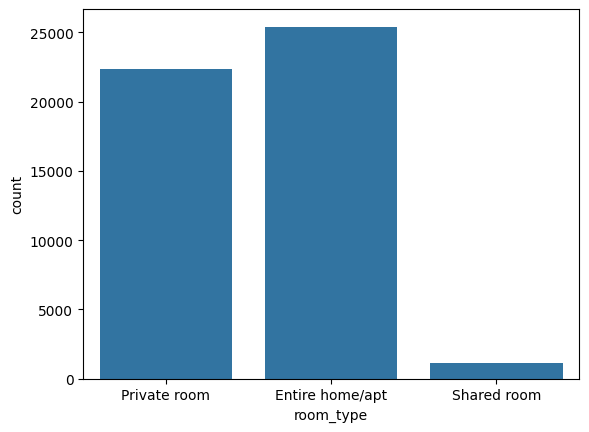

In [20]:
sns.countplot(x='room_type', data=df)

THe classes are imbalanced -> shared;Room is a small minority

In [23]:
df.select_dtypes(include='number').columns

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

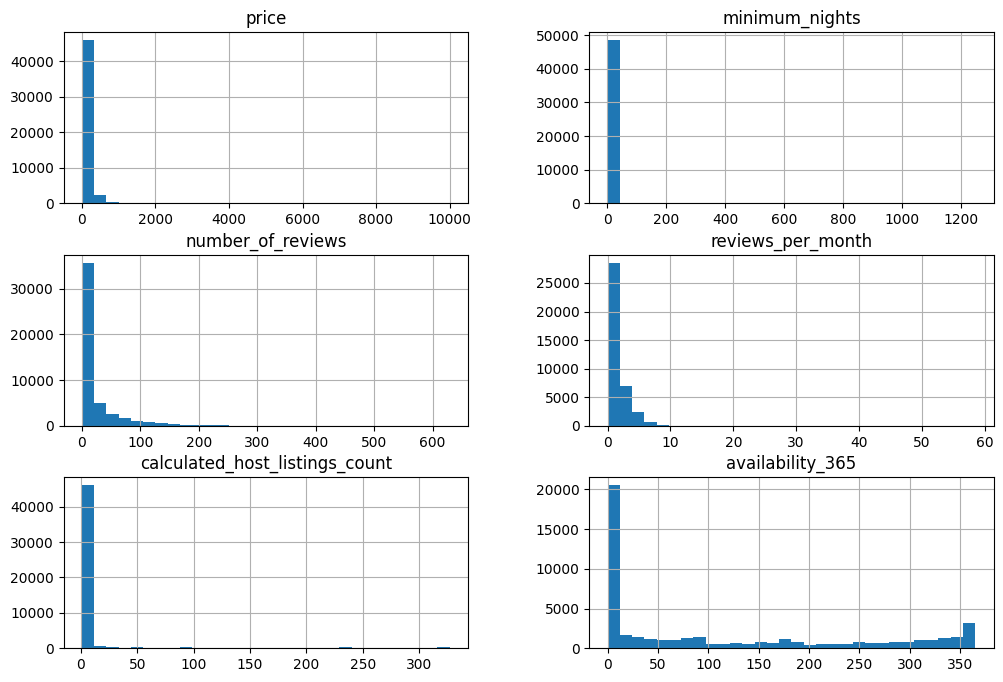

In [28]:
numerical_cols = ['price', 'minimum_nights','number_of_reviews', 'reviews_per_month',
                   'calculated_host_listings_count', 'availability_365']
df[numerical_cols].hist(bins= 30 ,figsize=(12,8))

<Axes: xlabel='neighbourhood_group', ylabel='count'>

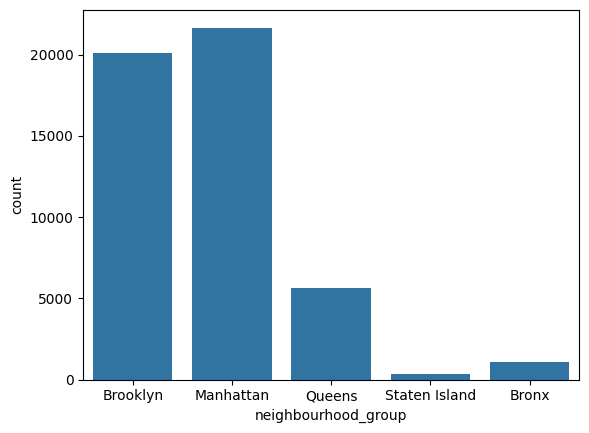

In [29]:
sns.countplot(data=df, x= 'neighbourhood_group')

<Axes: xlabel='room_type', ylabel='price'>

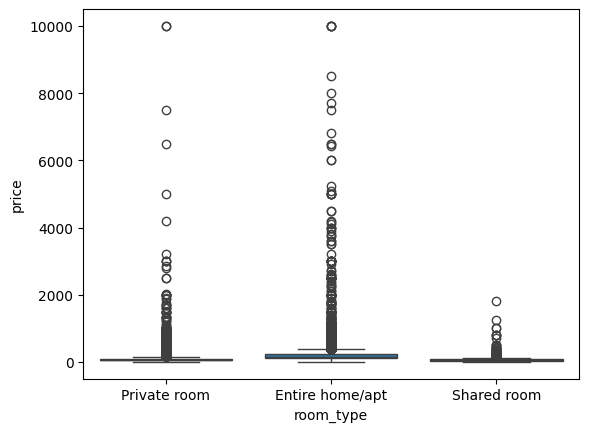

In [30]:
sns.boxplot(x='room_type', y='price',data=df)

#correlation netween numeric features

<Axes: >

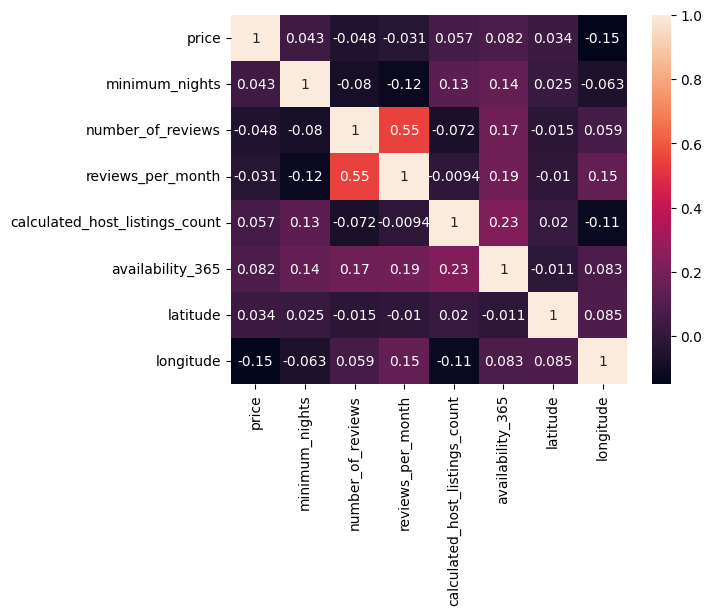

In [32]:
corr = df[numerical_cols + ['latitude','longitude']].corr()
sns.heatmap(corr,annot=True)

#geographic distribution(bonus visual)

<Axes: xlabel='longitude', ylabel='latitude'>

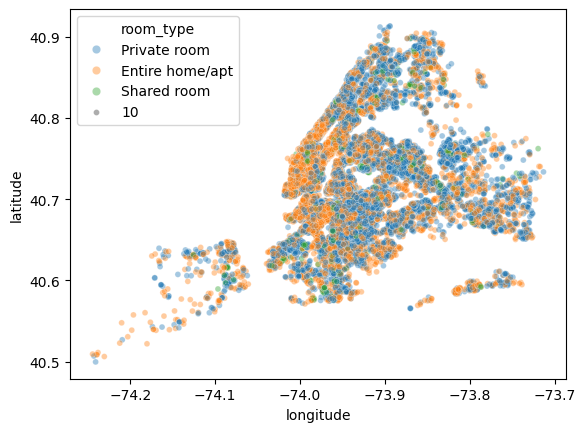

In [35]:
sns.scatterplot(x='longitude', y='latitude', data=df,hue= 'room_type',alpha=0.4, size = 10)

# Data cleaning

In [38]:
#1 drop columns that don't help us
df_clean = df.drop(columns=['id','name','host_id','host_name','last_review'])

#2 No reviews yet -> 0 reviews per month, not missing 
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [41]:
#3 cap extreme outliers instead of deleting rows.
price_cap = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)
df_clean

# df_clean = df_clean[df_clean['price'] < price_cap]

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


In [42]:
#4 separate x and y
X = df_clean.drop(columns=['room_type'])
y= df_clean['room_type']

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42,stratify=y)

In [44]:
#stratify ensures that whenever we split or sample, every group or class of original proportion will be maintain

In [54]:
df_clean[numerical_cols].skew()

latitude                          0.237167
longitude                         1.284210
price                             2.776321
minimum_nights                    2.360347
number_of_reviews                 3.690635
reviews_per_month                 3.300723
calculated_host_listings_count    7.933174
availability_365                  0.763408
dtype: float64

In [55]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer

In [66]:
numerical_cols = ['latitude','longitude','price', 'minimum_nights','number_of_reviews', 'reviews_per_month',
                   'calculated_host_listings_count', 'availability_365']
categorical_cols = ['neighbourhood_group', 'neighbourhood']

#1 pipeline- > for numeric columns
numeric_pipeline = Pipeline(steps = [
    ('impute',SimpleImputer(strategy='median') ),
    # ('skewness',PowerTransformer(method='yeo-johnson')), because of this overflow confditon occurs
    ('scale',StandardScaler())
])

#2 Pipeline -> for Categorical Columns
categorical_pipeline = Pipeline(steps=[
    ('impute',SimpleImputer(strategy="most_frequent") ),
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ("numerical",numeric_pipeline, numerical_cols),
    ("categorical",categorical_pipeline,categorical_cols)
])
preprocessor

,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [59]:
df_clean['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [67]:
import warnings
warnings.filterwarnings('ignore')

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [69]:
#class_weight="Balanced" tells the model to pay more attention to the minority class
# or rare class (shared room) but the problem is gradient boosting doesn't support class weight so we left it 
#as it is

models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree" : DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest" : RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    pipe = Pipeline(steps = [("preprocessor",preprocessor),("classifier",model)])

    # Accuracy alone can be misleading on imblanaced classes so we uses macro f1
    # both:plain accuracy and macro f1(which treats every class equally)
    accuracy = cross_val_score(pipe, X_train,y_train,cv = 3, scoring = "accuracy")
    macrof1 = cross_val_score(pipe, X_train,y_train,cv = 3, scoring = "f1_macro")

    print(f"{name}-> Accuracy : {accuracy.mean():.3f}, F1:{macrof1.mean():.3f}")

Logistic Regression-> Accuracy : 0.659, F1:0.522
Decision Tree-> Accuracy : 0.782, F1:0.647
Random Forest-> Accuracy : 0.851, F1:0.715
Gradient Boosting-> Accuracy : 0.850, F1:0.705


In [71]:
from sklearn.model_selection import RandomizedSearchCV
best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced"))
])
param_distribution = {
    "classifier__n_estimators" : [100,200,150,300],
    "classifier__max_depth" : [8,12,15,20,None],
    "classifier__min_samples_split" : [2,5,10],
}
search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring = "f1_macro",
    random_state=42
)
search.fit(X_train,y_train)

,estimator,Pipeline(step...'balanced'))])
,param_distributions,"{'classifier__max_depth': [8, 12, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [72]:
print("Best parametrs:",search.best_params_)
print("best CV MAcro-f1", search.best_score_)

Best parametrs: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}
best CV MAcro-f1 0.728370688653689


In [74]:
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score
best_pipeline = search.best_estimator_
y_pred = best_pipeline.predict(X_test)
print(f"Accuracy Score:{accuracy_score(y_test,y_pred)}")
print(f"F1 Score:{f1_score(y_test,y_pred, average = "macro")}")

Accuracy Score:0.8547967278135845
F1 Score:0.73535033268044


<Axes: >

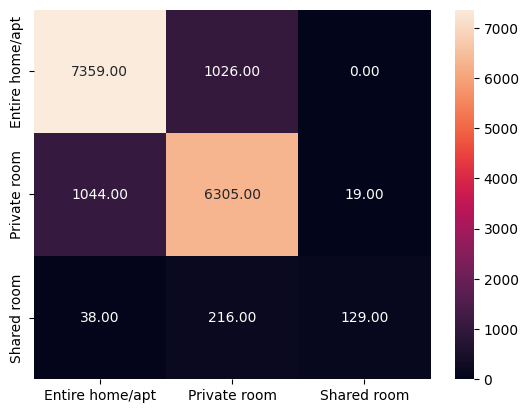

In [78]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="0.2f",xticklabels=best_pipeline.classes_,
           yticklabels=best_pipeline.classes_)

In [79]:
import joblib
joblib.dump(best_pipeline, "Model_Pipeline.pkl")

['Model_Pipeline.pkl']